# Deep Learning 2026: Hand-in Assignment 1
## Fully Connected Neural Network for MNIST Classification

**Convention:** rows = data points  
- `X`: (N, 784) — each row is one flattened image  
- `Y`: (N, 10) — one-hot encoded labels  
- `W_k`: (n_in, n_out), `b_k`: (1, n_out)  
- `Z_k = A_{k-1} @ W_k + b_k` (pre-activation)  
- `A_k = activation(Z_k)` (post-activation)

In [1]:
import numpy as np
import time
from pathlib import Path
import os, sys

# Ensure working directory contains MNIST/ and utils.py
_start_dir = Path.cwd().resolve()
for _p in [_start_dir] + list(_start_dir.parents):
    if (_p / 'MNIST').exists() and (_p / 'utils.py').exists():
        os.chdir(_p)
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from matplotlib import pyplot as plt
from utils import load_mnist, training_curve_plot

## Load Data

In [2]:
X_train, Y_train, X_test, Y_test = load_mnist()
print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_test:  {X_test.shape},  Y_test:  {Y_test.shape}")

X_train: (60000, 784), Y_train: (60000, 10)
X_test:  (10000, 784),  Y_test:  (10000, 10)


## Exercise 1: Neural Network Implementation

### 1. Initialization (He initialization)

In [3]:
def initialize(model):
    """
    Initialize parameters for a fully connected network using He initialization.
    
    param model: list of int, number of units in each layer, e.g. [784, 128, 64, 10]
    return: list of dicts, each with keys 'W' (weight matrix) and 'b' (bias vector)
    """
    params = []
    for k in range(len(model) - 1):
        n_in, n_out = model[k], model[k + 1]
        W = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)  # He initialization
        b = np.zeros((1, n_out))
        params.append({'W': W, 'b': b})
    return params

### 2. Activation Functions and Derivatives

In [4]:
def sigmoid(Z):
    """Sigmoid activation: a(z) = 1 / (1 + exp(-z))."""
    return 1.0 / (1.0 + np.exp(-Z))

def sigmoid_derivative(Z):
    """Derivative of sigmoid w.r.t. its input: sigmoid(z) * (1 - sigmoid(z))."""
    s = sigmoid(Z)
    return s * (1.0 - s)

def relu(Z):
    """ReLU activation: a(z) = max(0, z)."""
    return np.maximum(0, Z)

def relu_derivative(Z):
    """Derivative of ReLU w.r.t. its input: 1 if z > 0, else 0."""
    return np.where(Z > 0, 1.0, 0.0)

### 3. Forward Propagation

In [5]:
def forward_pass(X, params, activation_fn='relu'):
    """
    Forward propagation through all layers.
    Hidden layers use the chosen activation; the output layer is linear
    (softmax is applied in the cost function for numerical stability).
    
    param X: input data, shape (N, D_in)
    param params: list of dicts with 'W' and 'b' for each layer
    param activation_fn: 'relu' or 'sigmoid' for hidden layers
    return: dict with 'Z' (pre-activations) and 'A' (activations) for all layers
    """
    activation = relu if activation_fn == 'relu' else sigmoid
    K = len(params)
    
    A = [None] * (K + 1)
    Z = [None] * K
    A[0] = X
    
    for k in range(K):
        Z[k] = A[k] @ params[k]['W'] + params[k]['b']
        if k < K - 1:
            A[k + 1] = activation(Z[k])
        else:
            A[k + 1] = Z[k]  # linear output layer
    
    return {'Z': Z, 'A': A}

### 4. Softmax, Cost, and Gradient

Cross-entropy loss combined with softmax (Eq. 2 from assignment):
$$\ell_i = \log\left(\sum_{k=1}^{D_o} \exp(f_{ik})\right) - \sum_{k=1}^{D_o} \tilde{y}_{ik} f_{ik}, \quad L = \frac{1}{N}\sum_{i=1}^{N} \ell_i$$

Gradient: $\frac{\partial L}{\partial f} = \frac{1}{N}(\text{softmax}(f) - \tilde{y})$

In [6]:
def softmax(F):
    """Numerically stable softmax."""
    F_stable = F - np.max(F, axis=1, keepdims=True)
    exp_F = np.exp(F_stable)
    return exp_F / np.sum(exp_F, axis=1, keepdims=True)

def compute_cost(F, Y_onehot):
    """Cross-entropy cost combined with softmax (numerically stable)."""
    N = F.shape[0]
    F_stable = F - np.max(F, axis=1, keepdims=True)
    log_sum_exp = np.log(np.sum(np.exp(F_stable), axis=1))
    correct_class_score = np.sum(F_stable * Y_onehot, axis=1)
    return np.mean(log_sum_exp - correct_class_score)

def d_cost_d_output(F, Y_onehot):
    """Derivative of cross-entropy cost w.r.t. last-layer linear output."""
    N = F.shape[0]
    return (softmax(F) - Y_onehot) / N

### 5. Backward Propagation

In [7]:
def backward_pass(params, cache, Y_onehot, activation_fn='relu'):
    """
    Backward propagation through all layers.
    Returns gradients for all parameters.
    """
    act_deriv = relu_derivative if activation_fn == 'relu' else sigmoid_derivative
    Z, A = cache['Z'], cache['A']
    K = len(params)
    grads = [None] * K
    
    # Start from the output
    dA = d_cost_d_output(A[K], Y_onehot)
    
    for k in reversed(range(K)):
        if k == K - 1:
            dZ = dA  # output layer: no activation applied
        else:
            dZ = dA * act_deriv(Z[k])  # hidden layer
        
        grads[k] = {
            'dW': A[k].T @ dZ,
            'db': np.sum(dZ, axis=0, keepdims=True)
        }
        
        if k > 0:
            dA = dZ @ params[k]['W'].T
    
    return grads

### 6. Parameter Update

In [8]:
def update_parameters(params, grads, learning_rate):
    """
    Update parameters using gradient descent.
    
    param params: list of dicts with 'W' and 'b' for each layer
    param grads: list of dicts with 'dW' and 'db' for each layer
    param learning_rate: step size alpha
    return: updated params
    """
    for k in range(len(params)):
        params[k]['W'] -= learning_rate * grads[k]['dW']
        params[k]['b'] -= learning_rate * grads[k]['db']
    return params

### 7. Predict

In [9]:
def predict(X, Y_onehot, params, activation_fn='relu'):
    """
    Predict class labels and compute accuracy and cost.
    
    param X: input data, shape (N, D_in)
    param Y_onehot: one-hot encoded labels, shape (N, D_out)
    param params: trained model parameters
    param activation_fn: 'relu' or 'sigmoid'
    return: (predictions, accuracy, cost)
    """
    cache = forward_pass(X, params, activation_fn)
    F = cache['A'][-1]
    cost = compute_cost(F, Y_onehot)
    predictions = np.argmax(softmax(F), axis=1)
    true_labels = np.argmax(Y_onehot, axis=1)
    accuracy = np.mean(predictions == true_labels)
    return predictions, accuracy, cost

### 8. Mini-batch Generation

In [10]:
def random_mini_batches(X, Y, batch_size):
    """
    Randomly partition training data into mini-batches.
    
    param X: input data, shape (N, D_in)
    param Y: labels, shape (N, D_out)
    param batch_size: number of samples per mini-batch
    return: list of (X_mini, Y_mini) tuples
    """
    N = X.shape[0]
    indices = np.random.permutation(N)
    X_shuffled, Y_shuffled = X[indices], Y[indices]
    
    mini_batches = []
    num_complete = N // batch_size
    for i in range(num_complete):
        s, e = i * batch_size, (i + 1) * batch_size
        mini_batches.append((X_shuffled[s:e], Y_shuffled[s:e]))
    if N % batch_size != 0:
        mini_batches.append((X_shuffled[num_complete * batch_size:],
                             Y_shuffled[num_complete * batch_size:]))
    return mini_batches

### 9. Model Training

In [11]:
def train_model(X_train, Y_train, model, num_epochs, learning_rate, batch_size,
                activation_fn='relu', X_test=None, Y_test=None, eval_every=1):
    """
    Train a fully connected neural network with mini-batch gradient descent.
    
    param X_train: training input, shape (N, D_in)
    param Y_train: training labels (one-hot), shape (N, D_out)
    param model: list of int, architecture e.g. [784, 128, 64, 10]
    param num_epochs: number of training epochs
    param learning_rate: step size alpha
    param batch_size: number of samples per mini-batch
    param activation_fn: 'relu' or 'sigmoid' for hidden layers
    param X_test: optional test input for monitoring
    param Y_test: optional test labels for monitoring
    param eval_every: evaluate every k-th epoch
    return: (params, history dict, elapsed time in seconds)
    """
    params = initialize(model)
    train_costs, test_costs, train_accs, test_accs = [], [], [], []
    
    start = time.time()
    for epoch in range(1, num_epochs + 1):
        for X_mb, Y_mb in random_mini_batches(X_train, Y_train, batch_size):
            cache = forward_pass(X_mb, params, activation_fn)
            grads = backward_pass(params, cache, Y_mb, activation_fn)
            params = update_parameters(params, grads, learning_rate)
        
        if epoch % eval_every == 0 or epoch == 1:
            # Evaluate training cost/accuracy on the last mini-batch (as per assignment)
            _, tr_acc, tr_cost = predict(X_mb, Y_mb, params, activation_fn)
            train_costs.append(tr_cost); train_accs.append(tr_acc)
            
            if X_test is not None:
                _, te_acc, te_cost = predict(X_test, Y_test, params, activation_fn)
                test_costs.append(te_cost); test_accs.append(te_acc)
            
            msg = f"Epoch {epoch:3d}/{num_epochs} — Train: cost={tr_cost:.4f} acc={100*tr_acc:.2f}%"
            if X_test is not None:
                msg += f" | Test: cost={te_cost:.4f} acc={100*te_acc:.2f}%"
            print(msg)
    
    elapsed = time.time() - start
    history = {
        'train_cost': np.array(train_costs), 'test_cost': np.array(test_costs),
        'train_acc': np.array(train_accs), 'test_acc': np.array(test_accs)
    }
    return params, history, elapsed

## Exercise 2: Linear Model (0 Hidden Layers)

A linear model corresponds to `model = [784, 10]` — no hidden layers, just a direct mapping from input pixels to class logits. I should reach >90% test accuracy.

In [13]:
linear_model = [784, 10]
lr_linear = 0.1
bs_linear = 64
epochs_linear = 50

params_linear, hist_linear, elapsed_linear = train_model(
    X_train, Y_train,
    model=linear_model,
    num_epochs=epochs_linear,
    learning_rate=lr_linear,
    batch_size=bs_linear,
    activation_fn='relu',  # irrelevant: no hidden layers
    X_test=X_test, Y_test=Y_test,
)

Epoch   1/50 — Train: cost=0.2879 acc=90.62% | Test: cost=0.3391 acc=90.72%
Epoch   2/50 — Train: cost=0.3090 acc=93.75% | Test: cost=0.3066 acc=91.51%
Epoch   3/50 — Train: cost=0.1607 acc=96.88% | Test: cost=0.2990 acc=91.69%
Epoch   4/50 — Train: cost=0.3187 acc=96.88% | Test: cost=0.2890 acc=91.87%
Epoch   5/50 — Train: cost=0.2675 acc=87.50% | Test: cost=0.2845 acc=92.07%
Epoch   6/50 — Train: cost=0.1083 acc=96.88% | Test: cost=0.2820 acc=92.01%
Epoch   7/50 — Train: cost=0.2448 acc=96.88% | Test: cost=0.2794 acc=92.12%
Epoch   8/50 — Train: cost=0.2018 acc=90.62% | Test: cost=0.2774 acc=92.19%
Epoch   9/50 — Train: cost=0.3381 acc=87.50% | Test: cost=0.2769 acc=92.16%
Epoch  10/50 — Train: cost=0.1652 acc=90.62% | Test: cost=0.2741 acc=92.33%
Epoch  11/50 — Train: cost=0.2603 acc=87.50% | Test: cost=0.2761 acc=92.15%
Epoch  12/50 — Train: cost=0.0844 acc=100.00% | Test: cost=0.2725 acc=92.46%
Epoch  13/50 — Train: cost=0.2491 acc=90.62% | Test: cost=0.2707 acc=92.29%
Epoch  14/5

### Exercise 2(a): Training Curves

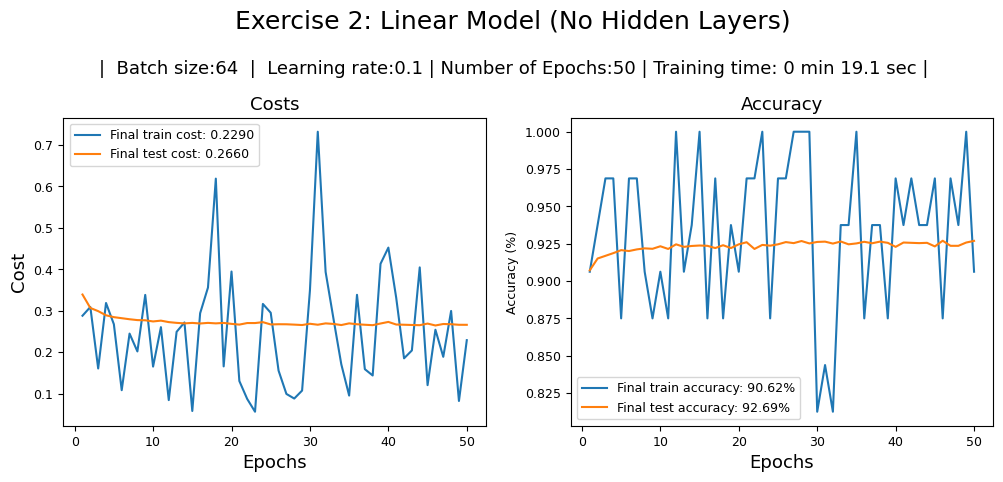

In [14]:
training_curve_plot(
    "Exercise 2: Linear Model (No Hidden Layers)",
    hist_linear['train_cost'], hist_linear['test_cost'],
    hist_linear['train_acc'], hist_linear['test_acc'],
    batch_size=bs_linear, learning_rate=lr_linear,
    num_epochs=epochs_linear, elapsed=elapsed_linear,
)
plt.savefig("exercise2_training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

### Exercise 2(b): Weight Visualization

Each column of the weight matrix W (shape 784×10) corresponds to one digit class.
Reshaped to 28×28, these show the "template" each class is looking for.

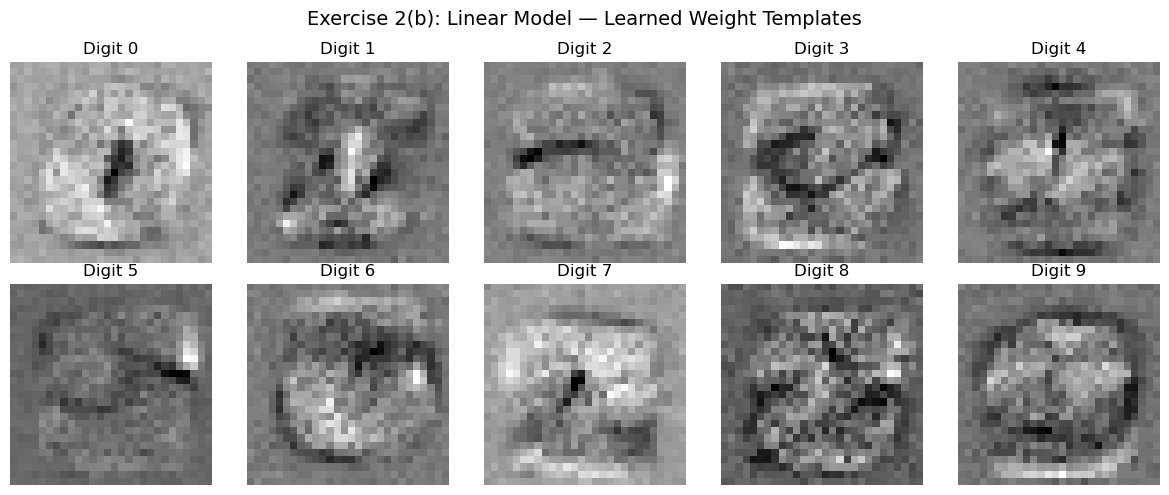

In [15]:
W = params_linear[0]['W']  # shape (784, 10)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Exercise 2(b): Linear Model — Learned Weight Templates", fontsize=14)
for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    img = W[:, digit].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Digit {digit}")
    ax.axis('off')
plt.tight_layout()
plt.savefig("exercise2_weights.png", dpi=150, bbox_inches='tight')
plt.show()

## Exercise 3: Multi-layer Neural Network

I train with two hidden layers [784, 128, 64, 10] using both ReLU and Sigmoid activations.
Target: ~97-98% test accuracy with ReLU.

### ReLU Activation

Epoch   1/50 — Train: cost=0.0637 acc=100.00% | Test: cost=0.1975 acc=94.05%
Epoch   2/50 — Train: cost=0.0223 acc=100.00% | Test: cost=0.1530 acc=95.27%
Epoch   3/50 — Train: cost=0.0052 acc=100.00% | Test: cost=0.1040 acc=96.73%
Epoch   4/50 — Train: cost=0.0434 acc=96.88% | Test: cost=0.1120 acc=96.34%
Epoch   5/50 — Train: cost=0.0046 acc=100.00% | Test: cost=0.0862 acc=97.19%
Epoch   6/50 — Train: cost=0.0179 acc=100.00% | Test: cost=0.1015 acc=96.79%
Epoch   7/50 — Train: cost=0.0152 acc=100.00% | Test: cost=0.0856 acc=97.31%
Epoch   8/50 — Train: cost=0.0019 acc=100.00% | Test: cost=0.0759 acc=97.56%
Epoch   9/50 — Train: cost=0.0037 acc=100.00% | Test: cost=0.0776 acc=97.69%
Epoch  10/50 — Train: cost=0.0022 acc=100.00% | Test: cost=0.0812 acc=97.65%
Epoch  11/50 — Train: cost=0.0048 acc=100.00% | Test: cost=0.0773 acc=97.71%
Epoch  12/50 — Train: cost=0.0024 acc=100.00% | Test: cost=0.0784 acc=97.65%
Epoch  13/50 — Train: cost=0.0013 acc=100.00% | Test: cost=0.0806 acc=97.62%


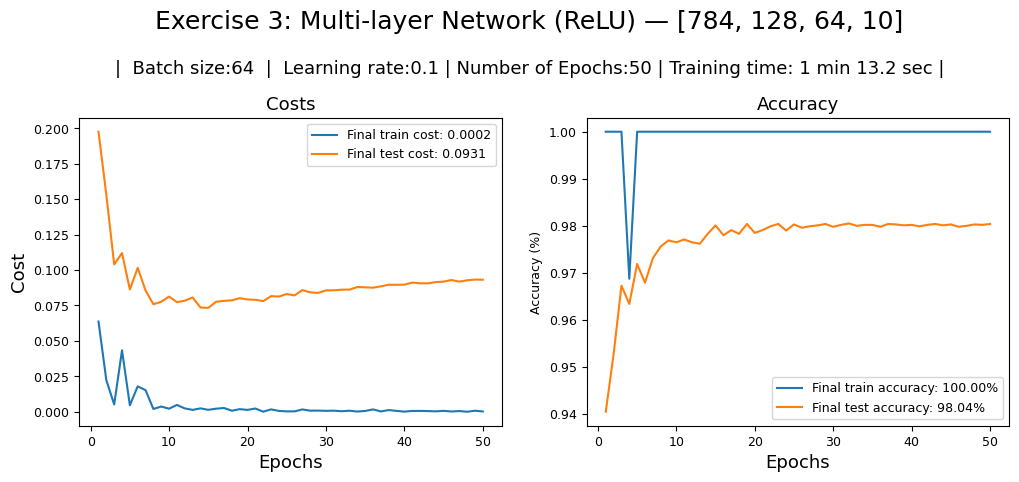

In [16]:
deep_model = [784, 128, 64, 10]

params_relu, hist_relu, elapsed_relu = train_model(
    X_train, Y_train,
    model=deep_model,
    num_epochs=50,
    learning_rate=0.1,
    batch_size=64,
    activation_fn='relu',
    X_test=X_test, Y_test=Y_test,
)

training_curve_plot(
    "Exercise 3: Multi-layer Network (ReLU) — [784, 128, 64, 10]",
    hist_relu['train_cost'], hist_relu['test_cost'],
    hist_relu['train_acc'], hist_relu['test_acc'],
    batch_size=64, learning_rate=0.1,
    num_epochs=50, elapsed=elapsed_relu,
)
plt.savefig("exercise3_relu.png", dpi=150, bbox_inches='tight')
plt.show()

### Sigmoid Activation

Epoch   1/50 — Train: cost=0.2439 acc=93.75% | Test: cost=0.2949 acc=90.88%
Epoch   2/50 — Train: cost=0.0540 acc=100.00% | Test: cost=0.2227 acc=93.18%
Epoch   3/50 — Train: cost=0.0341 acc=100.00% | Test: cost=0.1642 acc=95.04%
Epoch   4/50 — Train: cost=0.0576 acc=96.88% | Test: cost=0.1522 acc=95.46%
Epoch   5/50 — Train: cost=0.0162 acc=100.00% | Test: cost=0.1160 acc=96.38%
Epoch   6/50 — Train: cost=0.0158 acc=100.00% | Test: cost=0.1063 acc=96.70%
Epoch   7/50 — Train: cost=0.0118 acc=100.00% | Test: cost=0.1002 acc=96.94%
Epoch   8/50 — Train: cost=0.0120 acc=100.00% | Test: cost=0.0864 acc=97.36%
Epoch   9/50 — Train: cost=0.0047 acc=100.00% | Test: cost=0.0834 acc=97.39%
Epoch  10/50 — Train: cost=0.0050 acc=100.00% | Test: cost=0.0783 acc=97.58%
Epoch  11/50 — Train: cost=0.0071 acc=100.00% | Test: cost=0.0739 acc=97.63%
Epoch  12/50 — Train: cost=0.0053 acc=100.00% | Test: cost=0.0810 acc=97.50%
Epoch  13/50 — Train: cost=0.0081 acc=100.00% | Test: cost=0.0698 acc=97.84%
E

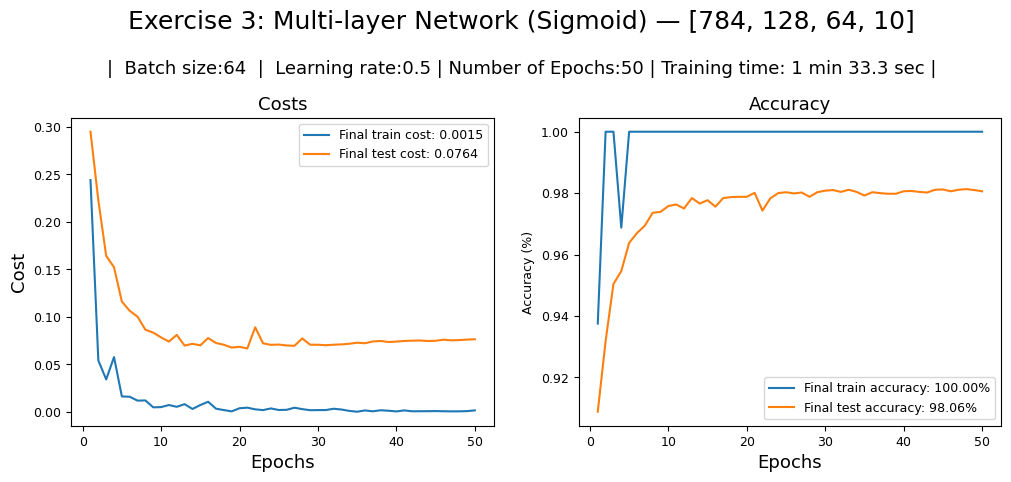

In [17]:
params_sig, hist_sig, elapsed_sig = train_model(
    X_train, Y_train,
    model=deep_model,
    num_epochs=50,
    learning_rate=0.5,
    batch_size=64,
    activation_fn='sigmoid',
    X_test=X_test, Y_test=Y_test,
)

training_curve_plot(
    "Exercise 3: Multi-layer Network (Sigmoid) — [784, 128, 64, 10]",
    hist_sig['train_cost'], hist_sig['test_cost'],
    hist_sig['train_acc'], hist_sig['test_acc'],
    batch_size=64, learning_rate=0.5,
    num_epochs=50, elapsed=elapsed_sig,
)
plt.savefig("exercise3_sigmoid.png", dpi=150, bbox_inches='tight')
plt.show()